# Инициализация датафрейма

In [138]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, f1_score, precision_score, recall_score,  confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import SGDClassifier


In [139]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [140]:
df = pd.read_csv("/content/drive/MyDrive/Data Science/lab_1/student_lifestyle_100k.csv", sep=",")
df.columns = df.columns.str.lower()
df.head()

,student_id,age,gender,department,cgpa,sleep_duration,study_hours,social_media_hours,physical_activity,stress_level,depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


# Обработка пропусков и дубликатов

In [141]:
df.info() # общая информация пока не очень помогает

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   student_id          100000 non-null  int64  
 1   age                 100000 non-null  int64  
 2   gender              100000 non-null  object 
 3   department          100000 non-null  object 
 4   cgpa                100000 non-null  float64
 5   sleep_duration      100000 non-null  float64
 6   study_hours         100000 non-null  float64
 7   social_media_hours  100000 non-null  float64
 8   physical_activity   100000 non-null  int64  
 9   stress_level        100000 non-null  int64  
 10  depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [142]:
df.isna().sum() # проверяем пропуски - их нет

,0
student_id,0
age,0
gender,0
department,0
cgpa,0
sleep_duration,0
study_hours,0
social_media_hours,0
physical_activity,0
stress_level,0


In [143]:
df.duplicated().sum() # проверяем полные дубликаты строк - их нет

np.int64(0)

In [144]:
s = df['sleep_duration'] + df['study_hours'] + df['social_media_hours']
s.max() # 27.3 - многовато, но совмещение учебы и просмотра ютуба возможно?

27.3

In [145]:
(s > 24).sum() # 79 - тем более таких наблюдений мизерный процент, оставляем

np.int64(79)

# Валидация каждого столбца

In [146]:
df.drop(columns=["student_id"], inplace=True) # ID нам вряд ли будет полезен, дропаем

In [147]:
print(min(df['age']))
print(max(df['age'])) # возраст в диапазоне 18-24, нормально

18
24


In [148]:
print(min(df['cgpa']))
print(max(df['cgpa'])) # разброс успеваемости соответствует заявленному

1.56
4.0


In [149]:
print(df['gender'].unique()) # только два пола, нормально

['Female' 'Male']


In [150]:
print(df['department'].unique()) # валидные направления

['Science' 'Engineering' 'Medical' 'Arts' 'Business']


In [151]:
print('Sleep min/max:')
print(min(df['sleep_duration']))
print(max(df['sleep_duration'])) # разброс времени сна нормальный

print('\nStudy min/max:')
print(min(df['study_hours']))
print(max(df['study_hours'])) # разброс времени учебы нормальный

print('\nSocial media min/max:')
print(min(df['social_media_hours']))
print(max(df['social_media_hours'])) # разброс времени на медиа нормальный

print('\nPhysical activity min/max:')
print(min(df['physical_activity']))
print(max(df['physical_activity'])) # 150 минут в неделю - маловато, но что поделать

print('\nStress min/max:')
print(min(df['stress_level']))
print(max(df['stress_level'])) # соответствует заявленному

Sleep min/max:
3.0
12.0

Study min/max:
0.0
12.8

Social media min/max:
0.0
10.0

Physical activity min/max:
0
149

Stress min/max:
2
10


In [152]:
print(df['depression'].unique()) # два типа, нормально

[False  True]


/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:7093: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


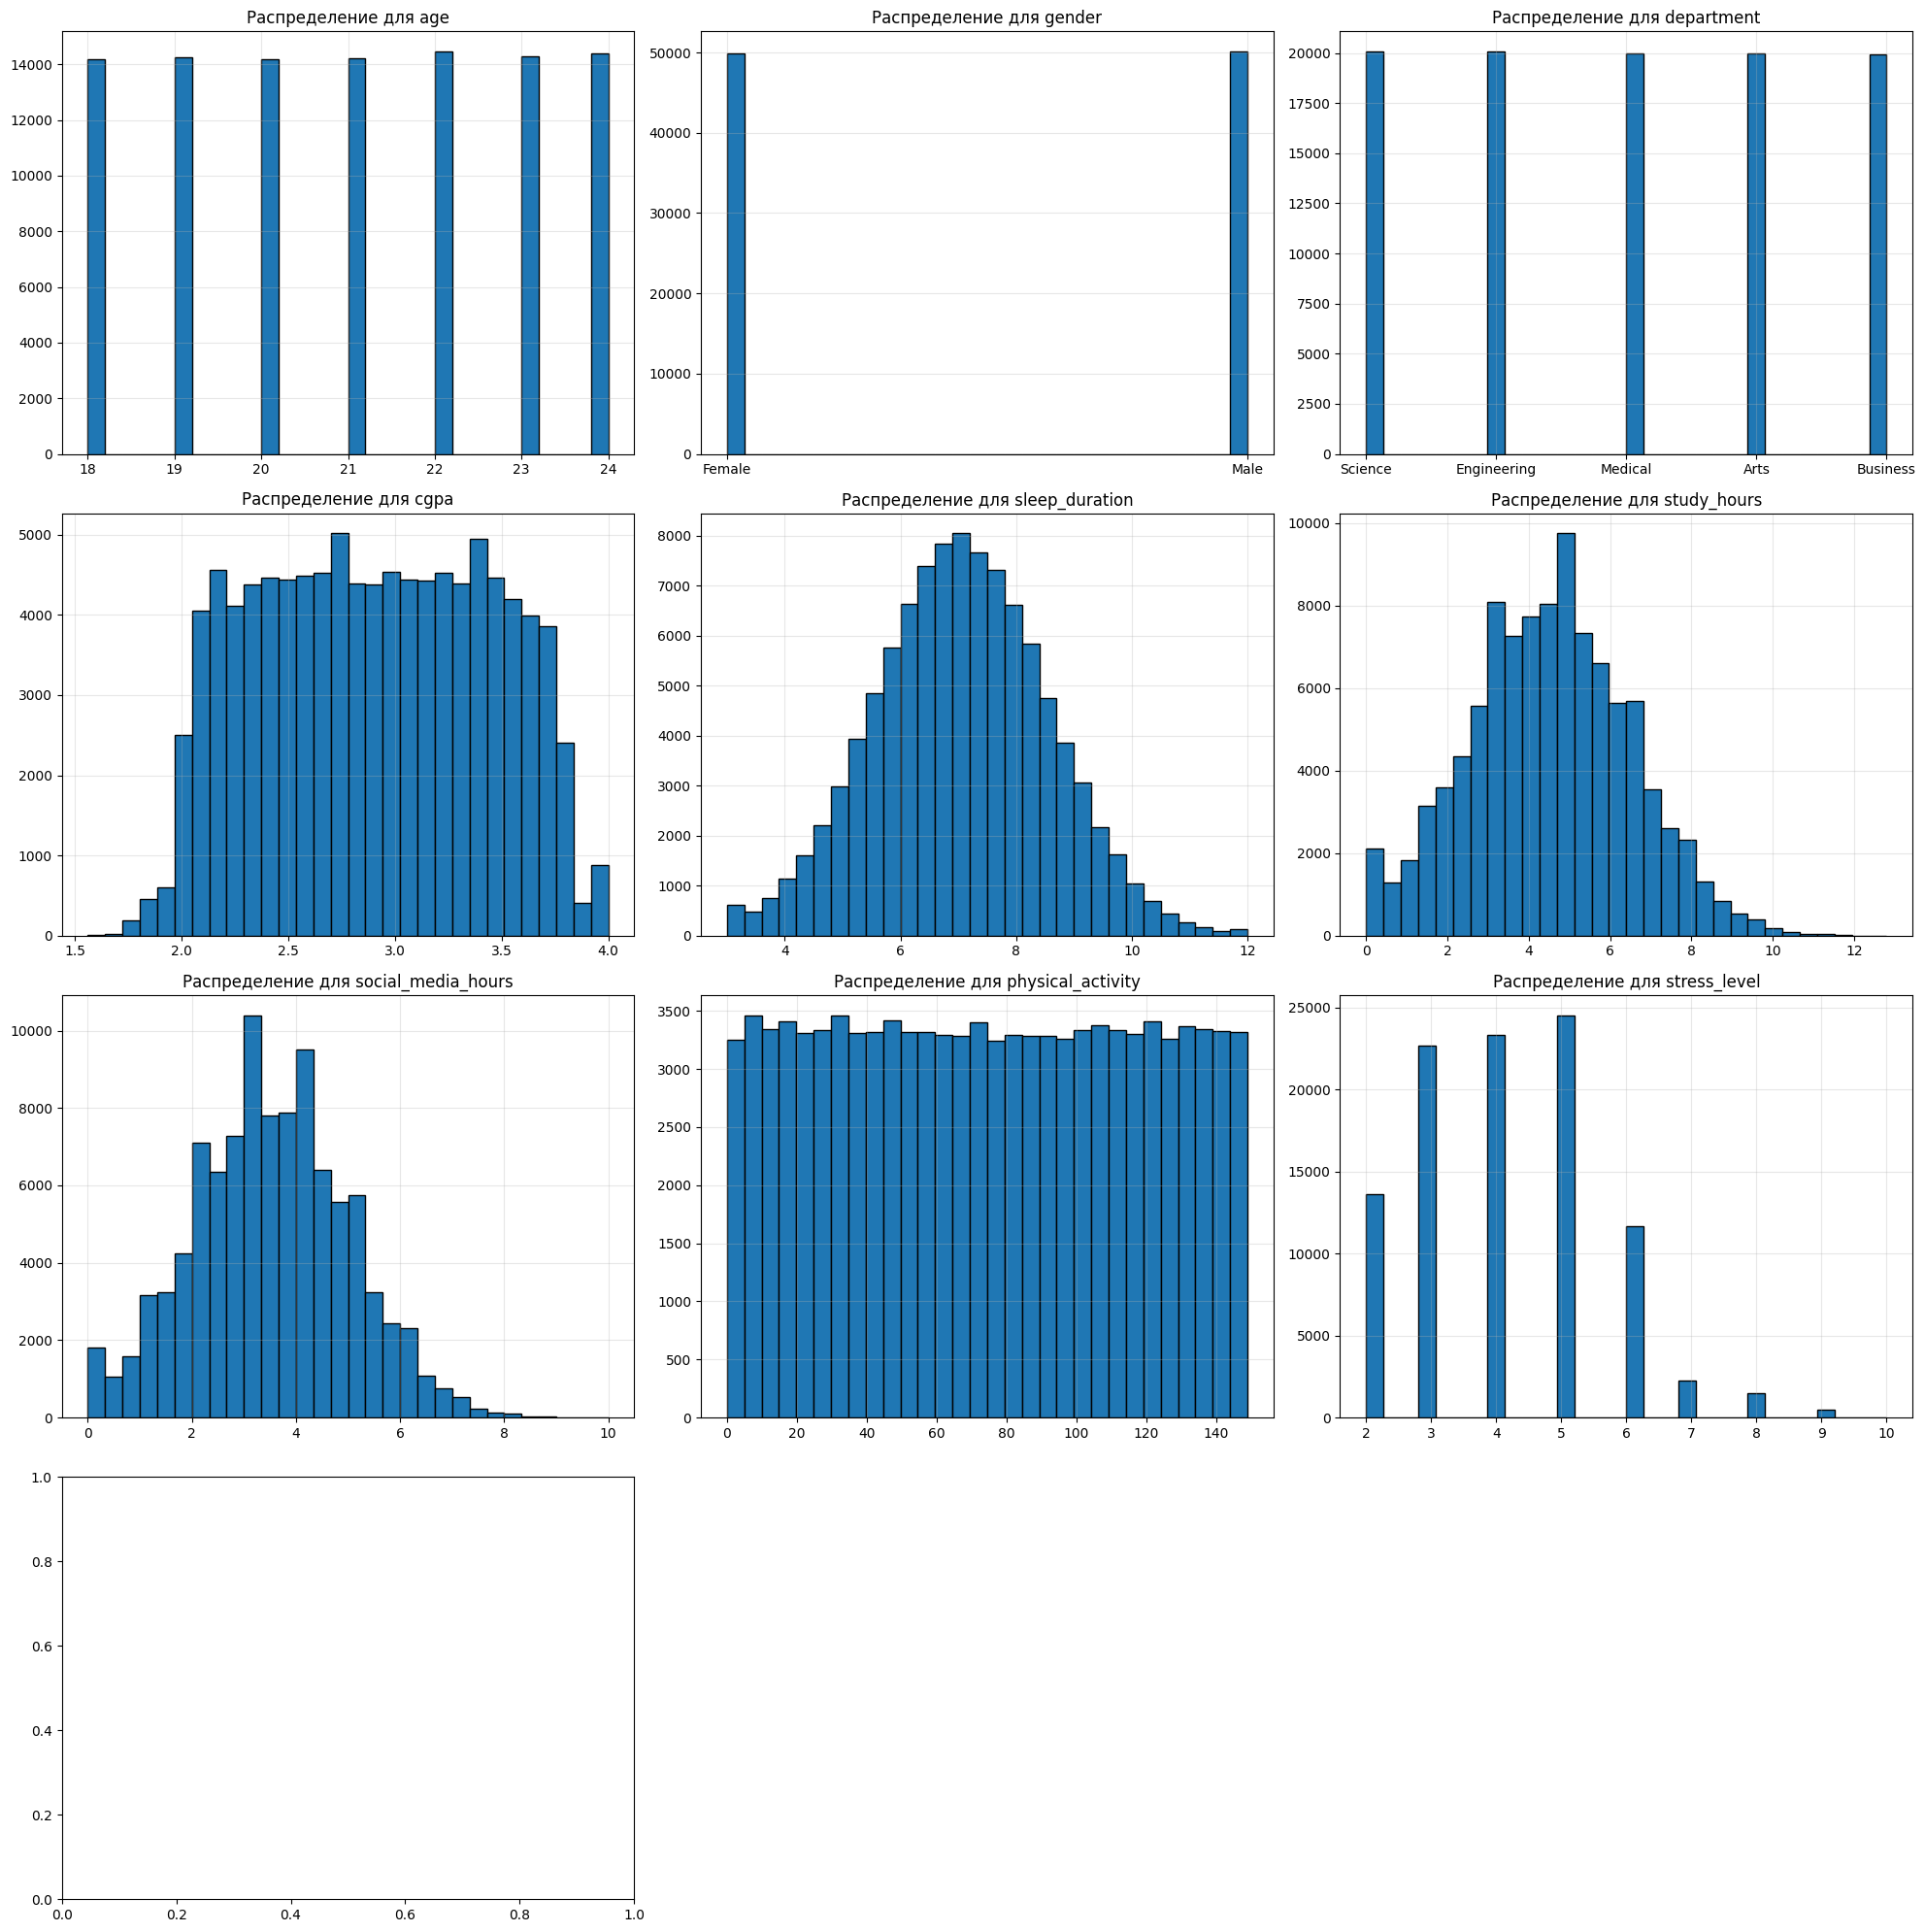

In [153]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20)) # строим график под каждый столбец для оценки распределения
axes = axes.flatten()

for i, col in enumerate(df.columns):
    try:
      axes[i].hist(df[col], bins=30, edgecolor='black')
      axes[i].set_title(f'Распределение для {col}')
      axes[i].grid(True, alpha=0.3)
    except:
      pass
for i in range(len(df.columns), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

В целом многие распределения близки к нормальному и даже равномерному, резких выбросов нет

Можно также построить "ящики с усами" на числовые фичи, чтобы оценить выбросы

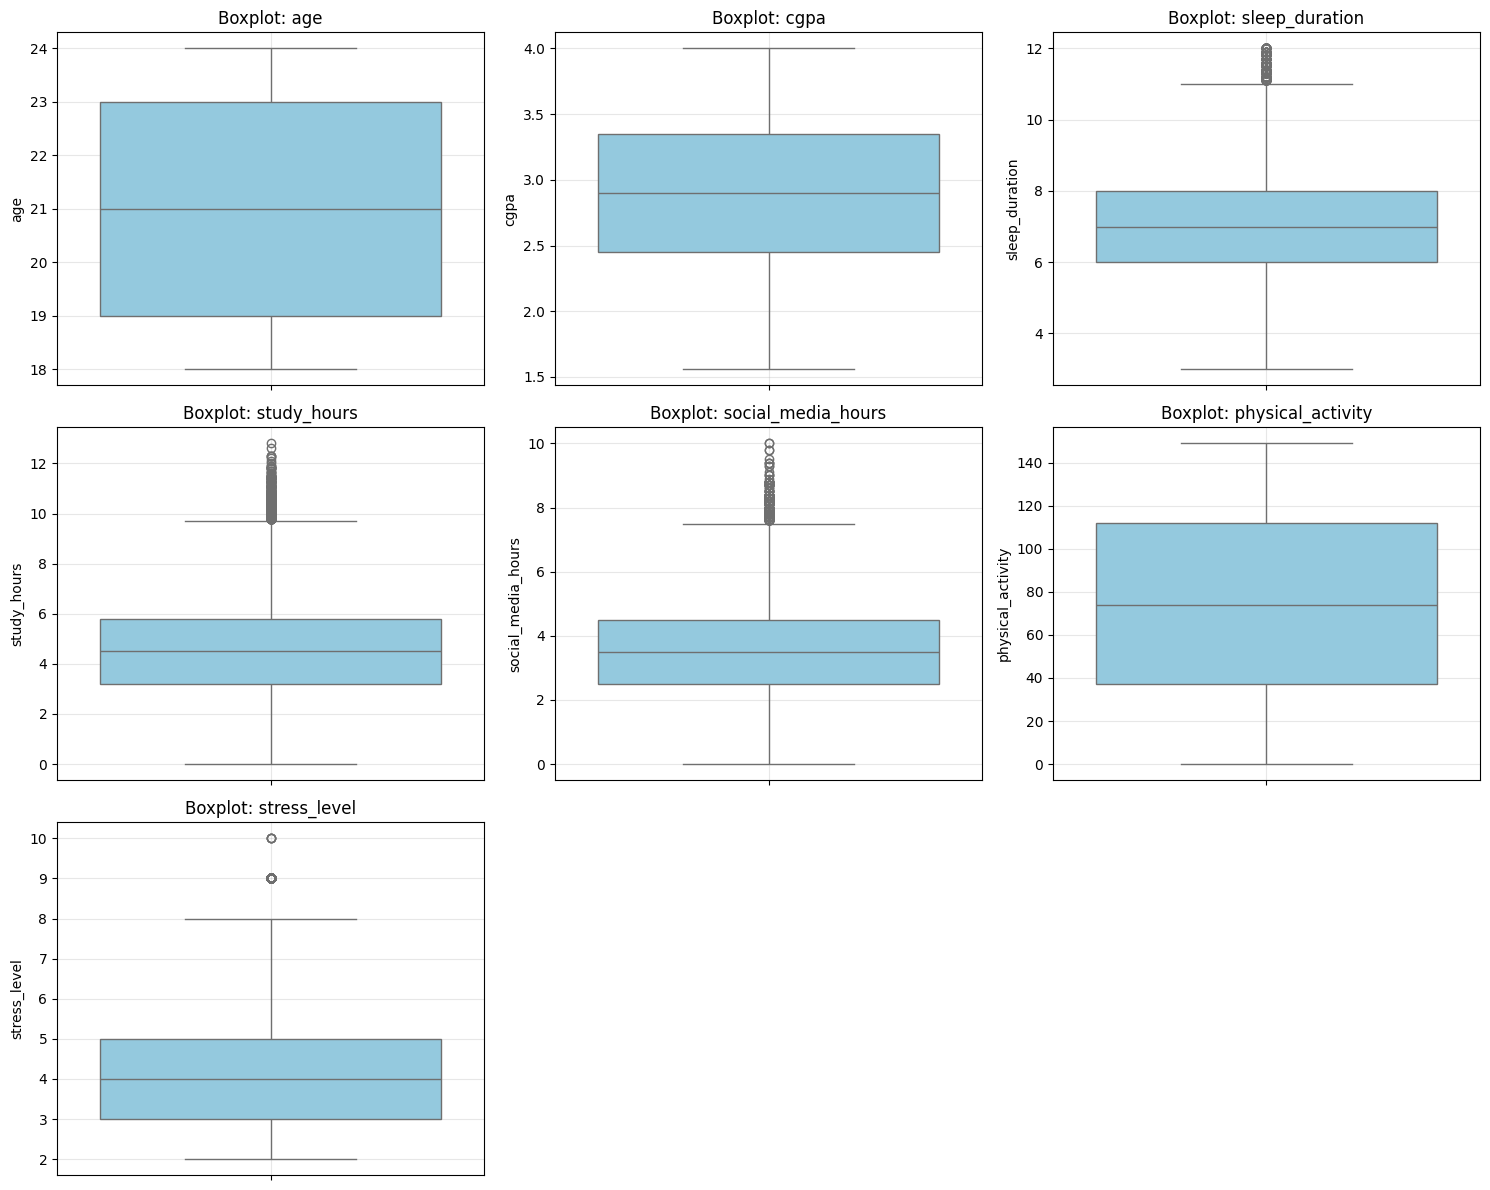

In [154]:
numeric_cols = ['age', 'cgpa', 'sleep_duration', 'study_hours',
                'social_media_hours', 'physical_activity', 'stress_level']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()


for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot: {col}', fontsize=12)
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

for i in range(len(numeric_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Выпадающих за усы точек мало и они в целом не являются ошибочными с логической точки зрения. Смысла их удалять, судя по всему, нет

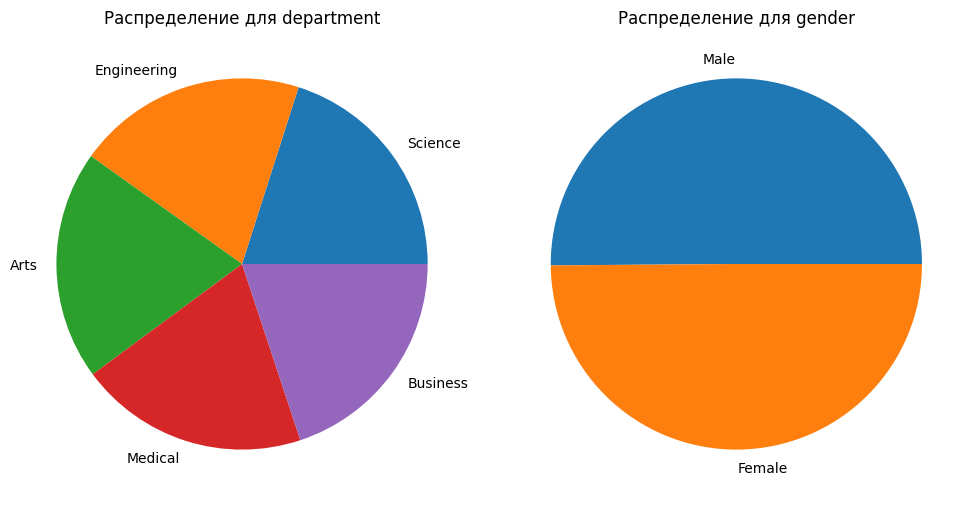

In [155]:
 # Отличное равномерное распределение категориальных признаков

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()

counts = df['department'].value_counts()
axes[0].pie(counts.values, labels=counts.index)
axes[0].set_title(f'Распределение для department')
axes[0].grid(True, alpha=0.3)

counts = df['gender'].value_counts()
axes[1].pie(counts.values, labels=counts.index)
axes[1].set_title(f'Распределение для gender')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [156]:
df['depression'] = df['depression'].astype(int) # булевы значения просто переводим в 0/1
df.head()

,age,gender,department,cgpa,sleep_duration,study_hours,social_media_hours,physical_activity,stress_level,depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,0
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,0
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,0
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,0
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,0


In [157]:
# Преобразуем категориальный столбец department в OHE
# Всего пять значений, поэтому OHE не создаст лишней нагрузки
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['department']])

# Создаем DataFrame с новыми столбцами и используем get_feature_names_out для создания имен
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['department']),
    index=df.index
)
# Удаляем исходный столбец и добавляем новые
df.drop('department', axis=1, inplace=True)
df = pd.concat([df, encoded_df], axis=1)
df.columns = df.columns.str.lower()
df.head()

,age,gender,cgpa,sleep_duration,study_hours,social_media_hours,physical_activity,stress_level,depression,department_arts,department_business,department_engineering,department_medical,department_science
0,22,Female,3.50,7.3,3.3,3.4,114,5,0,0.0,0.0,0.0,0.0,1.0
1,20,Male,2.72,5.5,7.2,6.0,142,2,0,0.0,0.0,1.0,0.0,0.0
2,20,Male,3.01,5.4,2.3,1.8,137,3,0,0.0,0.0,0.0,1.0,0.0
3,21,Male,3.63,8.1,2.0,4.6,130,3,0,0.0,0.0,1.0,0.0,0.0
4,19,Male,3.14,6.8,2.6,4.3,4,6,0,1.0,0.0,0.0,0.0,0.0


In [158]:
# в гендере всего две категории поэтому проще привести к бинарному формату как и bool
df['gender_encoded'] = (df['gender'] == 'Male').astype(int)
df.drop(columns='gender', inplace=True)
df.head()

,age,cgpa,sleep_duration,study_hours,social_media_hours,physical_activity,stress_level,depression,department_arts,department_business,department_engineering,department_medical,department_science,gender_encoded
0,22,3.50,7.3,3.3,3.4,114,5,0,0.0,0.0,0.0,0.0,1.0,0
1,20,2.72,5.5,7.2,6.0,142,2,0,0.0,0.0,1.0,0.0,0.0,1
2,20,3.01,5.4,2.3,1.8,137,3,0,0.0,0.0,0.0,1.0,0.0,1
3,21,3.63,8.1,2.0,4.6,130,3,0,0.0,0.0,1.0,0.0,0.0,1
4,19,3.14,6.8,2.6,4.3,4,6,0,1.0,0.0,0.0,0.0,0.0,1


# Синтез признаков

Можно попытаться создать несколько фичей на основе того, что есть

In [159]:
sleep_deficit = (df['sleep_duration'] < 7).astype(int) # недосып (бинарный)
heavy_study = (df['study_hours'] > 10).astype(int) # переработка (бинарная)
total_load = df['study_hours'] + df['social_media_hours'] # общая нагрузка на мозг в день

Эти три признака я создал изначально, но потом убедился, что линейно синтезированные фичи не улучшают линейную модель (и, судя по всему, могут ухудшить). Поэтому их добавлять в датафрейм не будем и попробуем создать что-то более сложное

In [160]:
df['efficiency'] = df['study_hours'] / df['sleep_duration']  # создание отношения может усилить зависимости

df['burnout_risk'] = (
    (df['study_hours'] > 8) &
    (df['sleep_duration'] < 6) &
    (df['social_media_hours'] > 3)
).astype(int) # более сложный бинарный признак выгорания

df['study_hours_sq'] = df['study_hours'] ** 2 # возведение в квадрат может усилить зависимости
df['sleep_duration_sq'] = df['sleep_duration'] ** 2

df['procrastination'] = df['social_media_hours'] / (df['study_hours'] + 0.1)

df['stress_study'] = df['stress_level'] * df['study_hours'] # усиляем вес стресса в случае с большим объемом учебной работы

Теперь сравним корелляции новых и старых признаков с таргетом

In [161]:
new_features = ['efficiency', 'burnout_risk', 'study_hours_sq', 'sleep_duration_sq', 'procrastination', 'stress_study']
old_features = ['study_hours', 'sleep_duration', 'social_media_hours']

correlations = df[new_features + old_features + ['cgpa']].corr()['cgpa']
print("- Корелляции с cgpa:\n")
print(correlations.sort_values(ascending=False))

correlations = df[new_features + old_features + ['depression']].corr()['depression']
print("\n\n- Корелляции с depression:\n")
print(correlations.sort_values(ascending=False))

- Корелляции с cgpa:

cgpa                  1.000000
study_hours_sq        0.119977
study_hours           0.099534
efficiency            0.073375
stress_study          0.067483
burnout_risk          0.033958
sleep_duration        0.015386
sleep_duration_sq     0.012219
procrastination      -0.022995
social_media_hours   -0.087998
Name: cgpa, dtype: float64


- Корелляции с depression:

depression            1.000000
stress_study          0.032834
efficiency            0.023005
social_media_hours    0.016771
procrastination       0.002828
burnout_risk          0.002169
study_hours          -0.015932
study_hours_sq       -0.018044
sleep_duration_sq    -0.048450
sleep_duration       -0.057529
Name: depression, dtype: float64


Есть неплохие корелляции, например квадрат времени сна явно связан с cgpa лучше, чем просто сон

Теперь стоит проверить, нет ли у нас слишком высоких связей между фичами

In [162]:
# Рассчитываем VIF для каждого признака
vif_data = pd.DataFrame({
    'feature': df.columns,
    'VIF': [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
})

# Сортируем по убыванию VIF
print(vif_data.sort_values('VIF', ascending=False))

                   feature         VIF
12      department_science  226.477828
10  department_engineering  226.325487
8          department_arts  225.835702
11      department_medical  225.286364
9      department_business  224.648153
2           sleep_duration  103.336469
17       sleep_duration_sq   75.857299
3              study_hours   37.754811
14              efficiency   24.555243
16          study_hours_sq   17.298034
19            stress_study   16.583709
6             stress_level    7.108232
18         procrastination    1.519044
15            burnout_risk    1.162867
5        physical_activity    1.115432
1                     cgpa    1.059848
4       social_media_hours    1.043885
7               depression    1.042072
0                      age    1.000218
13          gender_encoded    1.000212


Видимо, стоит удалить 'study_hours' и 'sleep_duration', потому что информация от них теперь зашита в других фичах, а дублирование информации может испортить линейную модель (VIF > 10 как раз говорит о повышенной корелляции)

In [163]:
df.drop(columns = ['study_hours', 'sleep_duration'], inplace=True)

In [164]:
# Рассчитываем VIF для каждого признака
vif_data = pd.DataFrame({
    'feature': df.columns,
    'VIF': [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
})

# Сортируем по убыванию VIF
print(vif_data.sort_values('VIF', ascending=False))

                   feature        VIF
10      department_science  48.365181
8   department_engineering  48.340895
6          department_arts  48.254676
9       department_medical  48.109746
7      department_business  48.030432
17            stress_study  13.598512
12              efficiency  10.180805
14          study_hours_sq   7.843865
4             stress_level   5.437057
15       sleep_duration_sq   2.760431
16         procrastination   1.273090
3        physical_activity   1.107599
13            burnout_risk   1.075707
1                     cgpa   1.058740
5               depression   1.040967
2       social_media_hours   1.036806
0                      age   1.000210
11          gender_encoded   1.000203


Теперь дублирования стало меньше и VIF принимает допустимые значения (кроме столбцов OHE, но для них это допустимо, так как они всегда имеют высокий VIF как минимум из-за связей между собой)

# Обучение линейной регрессии

In [165]:
 # отделяем верные ответы
y = df['cgpa']
X = df.drop(columns='cgpa')

# разбиваем выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [166]:
scaler = StandardScaler()
# выделяем колонки которые нуждаются в нормализации (не OHE, не бинарные и не таргет)
# StandardScaler выбран потому что многие признаки имеют нормальное распределение. К тому же, линейные модели лучше работают именно с ним и ограничение диапазона не критично
numeric_columns = ['age','social_media_hours', 'physical_activity', 'stress_level', 'efficiency', 'study_hours_sq', 'sleep_duration_sq', 'procrastination', 'stress_study']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])
X_train_scaled.head()

,age,social_media_hours,physical_activity,stress_level,depression,department_arts,department_business,department_engineering,department_medical,department_science,gender_encoded,efficiency,burnout_risk,study_hours_sq,sleep_duration_sq,procrastination,stress_study
75220,-1.504036,1.477176,-0.930663,1.309994,0,0.0,1.0,0.0,0.0,0.0,1,-0.358900,0,-0.348140,0.311747,-0.033143,0.603116
48955,1.494653,-1.077272,-0.861437,-0.795570,0,0.0,1.0,0.0,0.0,0.0,0,0.181970,0,-0.161724,-0.598626,-0.242221,-0.445900
44966,0.495090,0.468841,-0.353777,-0.795570,0,0.0,0.0,0.0,1.0,0.0,0,-0.216235,0,-0.112472,0.456879,-0.135394,-0.418294
13568,1.494653,-1.413384,0.961524,-0.795570,0,0.0,1.0,0.0,0.0,0.0,0,0.538346,0,0.149675,-0.713600,-0.274016,-0.280266
92727,1.494653,0.939397,-1.715228,-0.093715,0,1.0,0.0,0.0,0.0,0.0,1,0.637112,0,1.539850,0.681645,-0.183694,0.971191


In [167]:
# создаем и обучаем регрессию
model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)

y_test_pred = model.predict(X_test_scaled)

# Оценка результатов и метрик

In [168]:
# Метрики для тренировочной выборки
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
# Метрики для тестовой выборки
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)


print(f"MSE (train): {train_mse}\nRMSE (train): {train_rmse}\nMAE (train): {train_mae}\nR2 (train): {train_r2}\n")
print(f"MSE (test): {test_mse}\nRMSE (test): {test_rmse}\nMAE (test): {test_mae}\nR2 (test): {test_r2}")

MSE (train): 0.26716409046415
RMSE (train): 0.5168791836243263
MAE (train): 0.4425733453357797
R2 (train): 0.056518610025213856

MSE (test): 0.26919404178360373
RMSE (test): 0.518839129002048
MAE (test): 0.4448690534150764
R2 (test): 0.05109876127707336


In [169]:
# смотрим среднее значение и стандартное отклонение таргета для сравнения
std_target = y.std()
mean_target = y.mean()
print(std_target)
print(mean_target)

0.5322402229539693
2.8983157


Две выборки показывают схожие результаты - значит, модель не переобучилась. Но метрики не очень хорошие

R2 сильно меньше чем 1 (около нуля) - результаты близки к результатам модели, постоянно предсказывающей среднее значение. У нас разброс таргетов около 0.5, поэтому околонулевой R2 непростителен

RMSE почти равен стандартному отклонению - это при том, что стандартное отклонение является RMSE модели, постоянно предсказывающей среднее значение

MAE около 0.5 - в рамках шкалы CGPA (0-4) это серьезная погрешность

In [170]:
# Проверим линейные корелляции признаков

correlations = df.corr()['cgpa'].sort_values(ascending=False)
print(correlations)

cgpa                      1.000000
study_hours_sq            0.119977
efficiency                0.073375
stress_study              0.067483
burnout_risk              0.033958
sleep_duration_sq         0.012219
physical_activity         0.004766
department_arts           0.004140
age                       0.003248
department_science       -0.000305
department_business      -0.000601
department_engineering   -0.001111
department_medical       -0.002124
gender_encoded           -0.005163
stress_level             -0.012287
procrastination          -0.022995
social_media_hours       -0.087998
depression               -0.178971
Name: cgpa, dtype: float64


Линейные корелляции между признаками и таргетом предельно низкие, поэтому дело скорее всего не в модели, а в данных

In [171]:
# обрабатываем данные аналогично нашему пайплайну для создания learning_curve
scaler_for_curve = StandardScaler()
X_for_curve_scaled = X.copy()
X_for_curve_scaled[numeric_columns] = scaler_for_curve.fit_transform(X_for_curve_scaled[numeric_columns])


In [172]:
# собираем данные обучения на разных объемах выборок
train_sizes, train_scores, test_scores = learning_curve(
    model, X_for_curve_scaled, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2'
    )

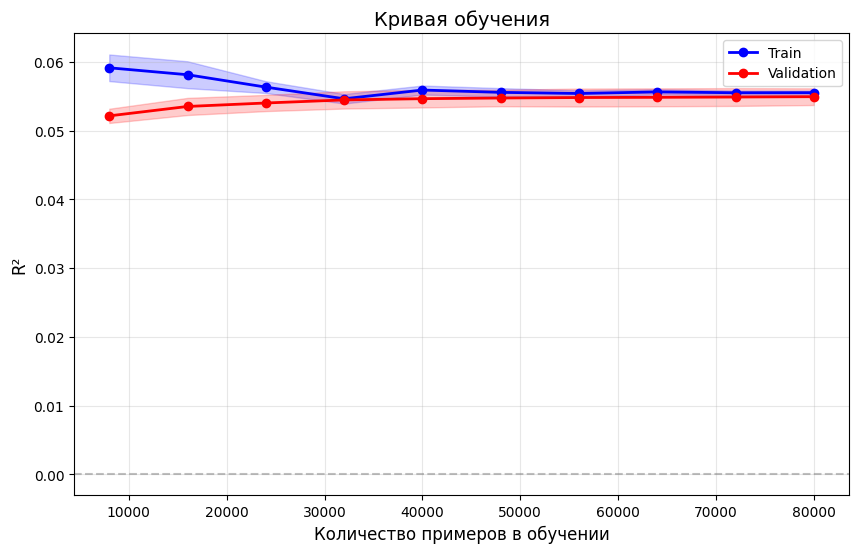

In [173]:
# смотрим график по learning_curve чтобы оценить динамику R2 на разных выборках

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, 'o-', label='Train', color='blue', linewidth=2)
plt.plot(train_sizes, test_mean, 'o-', label='Validation', color='red', linewidth=2)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.2, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 alpha=0.2, color='red')

plt.xlabel('Количество примеров в обучении', fontsize=12)
plt.ylabel('R²', fontsize=12)
plt.title('Кривая обучения', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.show()

R2 сохраняет примерно одинаковое околонулевое значение на всех аргументах. Делаем вывод, что модель не зависит от объема выборки и показывает слабые результаты в любом случае

/tmp/ipykernel_35683/2947587735.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальный прогноз', color='red')


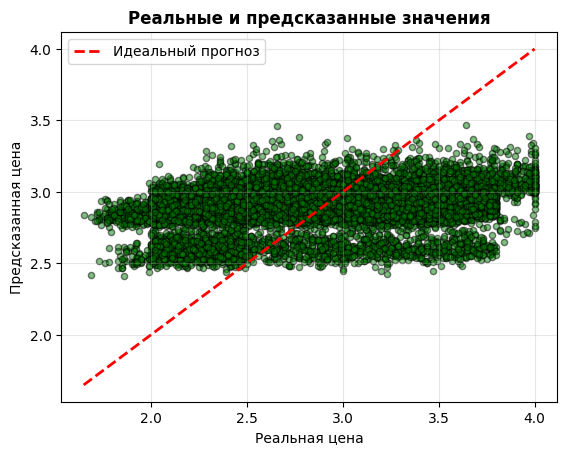

In [174]:
# смотрим отличие предсказанных данных от реальных

plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='black', s=20, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальный прогноз', color='red')
plt.xlabel('Реальная цена', fontsize=10)
plt.ylabel('Предсказанная цена', fontsize=10)
plt.title('Реальные и предсказанные значения', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Видим, что модель предсказывает примерно одно и то же каждый раз и не ловит корелляции

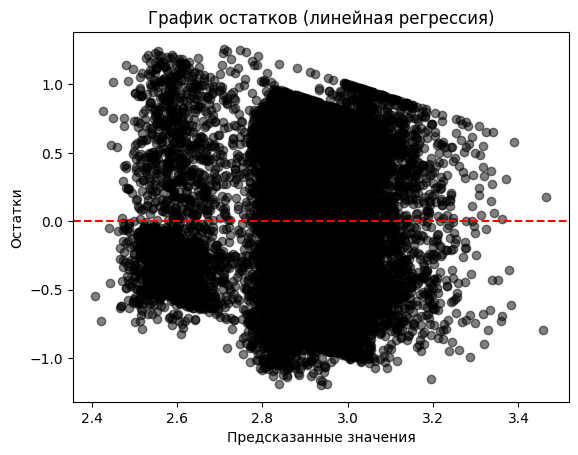

In [175]:
residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals, alpha=0.5, color='black')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков (линейная регрессия)')
plt.show()

На графике остатков можно заметить некие подобия наклонных прямых, но избежать их путем синтеза фичей не удалось. Возможно, эти линии являются последствием околоконстантного предсказания модели.

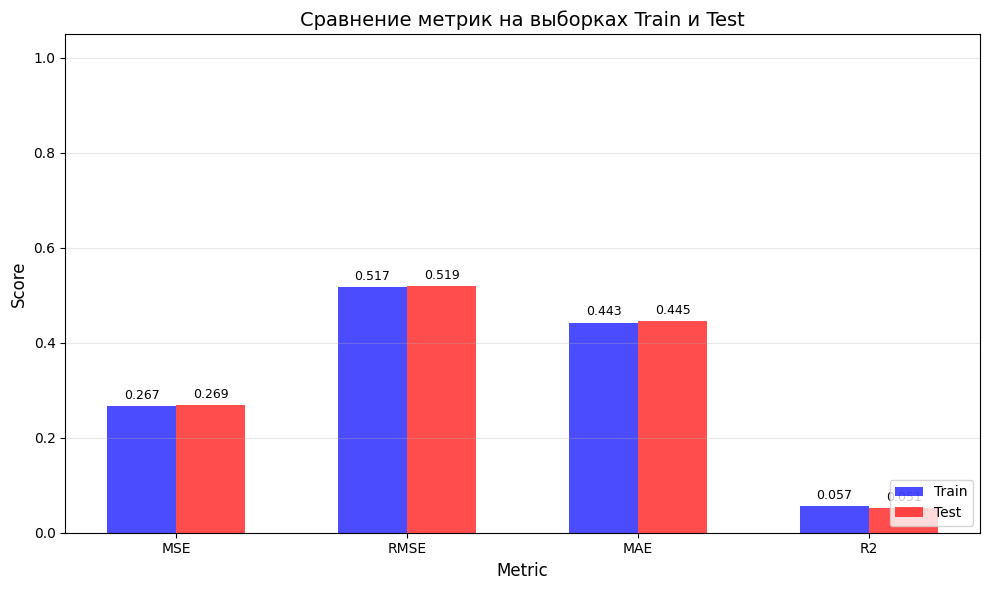

In [176]:
metrics = ['MSE', 'RMSE', 'MAE', 'R2']
train_scores = [train_mse, train_rmse, train_mae, train_r2]
test_scores = [test_mse, test_rmse, test_mae, test_r2]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, train_scores, width, label='Train', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, test_scores, width, label='Test', color='red', alpha=0.7)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Metric', fontsize=12)
ax.set_title('Сравнение метрик на выборках Train и Test', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Метрики на выборках практически совпадают, что доказывает отсутствие переобучения

# Обучение логистической регрессии

In [177]:
 # отделяем верные ответы
y = df['depression']
X = df.drop(columns='depression')

In [178]:
# разбиваем выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [179]:
scaler = StandardScaler()
# выделяем колонки которые нуждаются в нормализации (не OHE, не бинарные и не таргет)
numeric_columns = ['age', 'cgpa', 'social_media_hours', 'physical_activity', 'stress_level', 'efficiency', 'study_hours_sq', 'sleep_duration_sq', 'procrastination', 'stress_study']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])
X_train_scaled.head()

,age,cgpa,social_media_hours,physical_activity,stress_level,department_arts,department_business,department_engineering,department_medical,department_science,gender_encoded,efficiency,burnout_risk,study_hours_sq,sleep_duration_sq,procrastination,stress_study
75220,-1.504036,-1.479523,1.477176,-0.930663,1.309994,0.0,1.0,0.0,0.0,0.0,1,-0.358900,0,-0.348140,0.311747,-0.033143,0.603116
48955,1.494653,-0.314406,-1.077272,-0.861437,-0.795570,0.0,1.0,0.0,0.0,0.0,0,0.181970,0,-0.161724,-0.598626,-0.242221,-0.445900
44966,0.495090,-0.314406,0.468841,-0.353777,-0.795570,0.0,0.0,0.0,1.0,0.0,0,-0.216235,0,-0.112472,0.456879,-0.135394,-0.418294
13568,1.494653,0.324528,-1.413384,0.961524,-0.795570,0.0,1.0,0.0,0.0,0.0,0,0.538346,0,0.149675,-0.713600,-0.274016,-0.280266
92727,1.494653,-0.483536,0.939397,-1.715228,-0.093715,1.0,0.0,0.0,0.0,0.0,1,0.637112,0,1.539850,0.681645,-0.183694,0.971191


In [180]:
# создаем и обучаем регрессию
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)

y_test_pred = model.predict(X_test_scaled)

# Оценка результатов и метрик


In [181]:
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy (train): {train_accuracy}\nPrecision (train): {train_precision}\nRecall (train): {train_recall}\nF1 (train): {train_f1}\n")
print(f"Accuracy (test): {test_accuracy}\nPrecision (test): {test_precision}\nRecall (test): {test_recall}\nF1 (test): {test_f1}")

Accuracy (train): 0.8993125
Precision (train): 0.75
Recall (train): 0.00037234702742956435
F1 (train): 0.000744324525493115

Accuracy (test): 0.8997
Precision (test): 0.0
Recall (test): 0.0
F1 (test): 0.0


Высокий accuracy и низкие (нулевые 😵‍💫) precision/recall - минорный класс депрессии не распознается моделью. Попробуем изменить параметры модели

In [182]:
# создаем и обучаем регрессию с параметом class_weight для высоких штрафов за ошибки на минорном классе (депрессии)
model = LogisticRegression(class_weight='balanced')

model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)

y_test_pred = model.predict(X_test_scaled)

In [183]:
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy (train): {train_accuracy}\nPrecision (train): {train_precision}\nRecall (train): {train_recall}\nF1 (train): {train_f1}\n")
print(f"Accuracy (test): {test_accuracy}\nPrecision (test): {test_precision}\nRecall (test): {test_recall}\nF1 (test): {test_f1}")

Accuracy (train): 0.6274625
Precision (train): 0.16901065449010655
Recall (train): 0.6890902320963138
F1 (train): 0.27144498496589825

Accuracy (test): 0.6262
Precision (test): 0.16398476845596363
Recall (test): 0.6658354114713217
F1 (test): 0.2631578947368421


Теперь модель распознает 70% случаев депрессии (recall), но в то же время вызывает больше ложных тревог - только 16% предсказанных случаев депрессии верны (precision). В целом по логике задачи такой результат можно считать более валидным

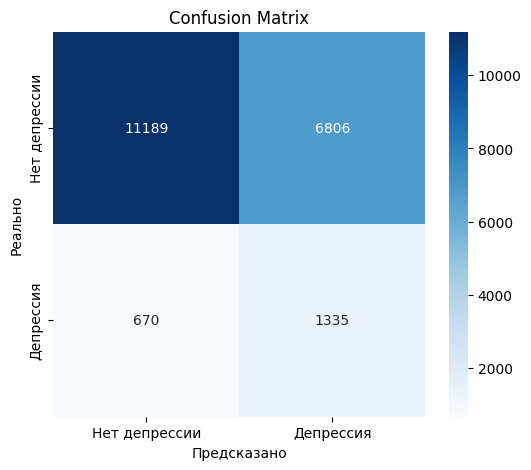

In [184]:
# строим confusion_matrix для оценки распределения предиктов
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет депрессии', 'Депрессия'],
            yticklabels=['Нет депрессии', 'Депрессия'])
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Confusion Matrix')
plt.show()

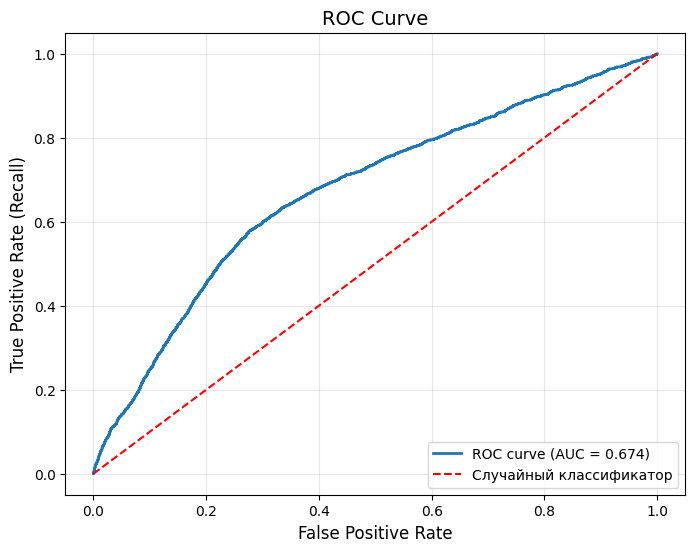

In [185]:
# строим ROC-AUC кривую
y_proba = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Случайный классификатор')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

Судя по ROC-AUC, имеется порог, в котором модель имеет почти вдвое больший TPR чем FPR (~ 0.7 / 0.3). Но до идеала далеко.

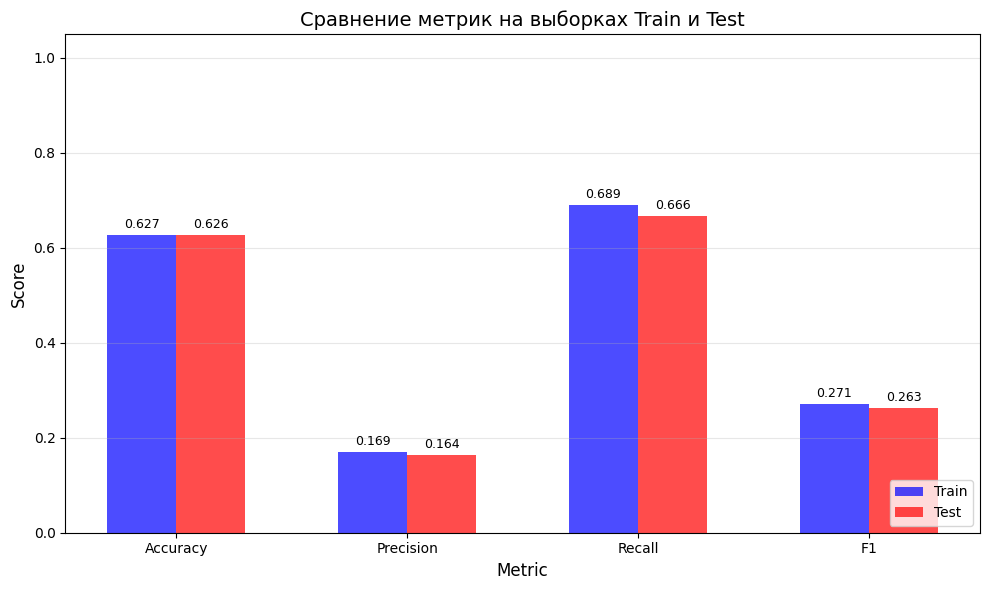

In [186]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, train_scores, width, label='Train', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, test_scores, width, label='Test', color='red', alpha=0.7)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Metric', fontsize=12)
ax.set_title('Сравнение метрик на выборках Train и Test', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Метрики на выборках практически совпадают, что доказывает отсутствие переобучения

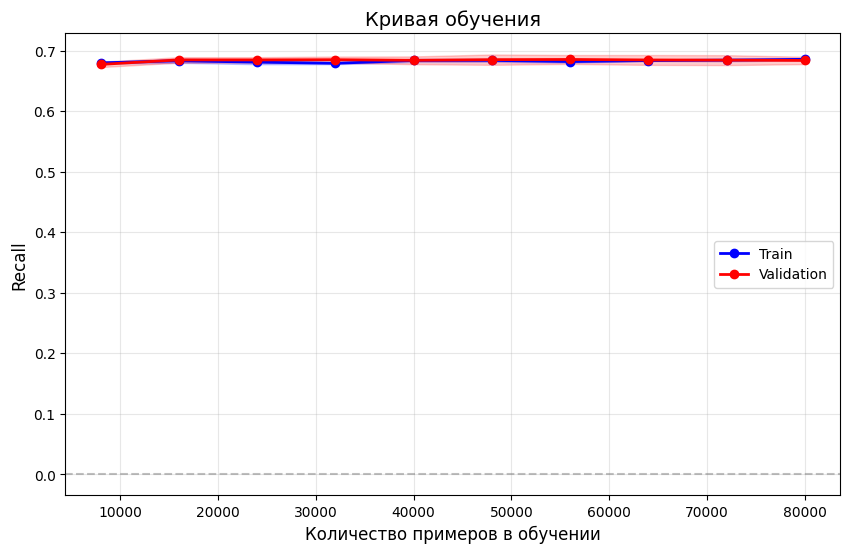

In [187]:
# обрабатываем данные аналогично нашему пайплайну для создания learning_curve
numeric_columns = ['age', 'cgpa', 'social_media_hours', 'physical_activity', 'stress_level', 'efficiency', 'study_hours_sq', 'sleep_duration_sq', 'procrastination', 'stress_study']
scaler_for_curve = StandardScaler()
X_for_curve_scaled = X.copy()
X_for_curve_scaled[numeric_columns] = scaler_for_curve.fit_transform(X_for_curve_scaled[numeric_columns])

# собираем данные обучения на разных объемах выборок
train_sizes, train_scores, test_scores = learning_curve(
    model, X_for_curve_scaled, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='recall'
    )

# смотрим график по learning_curve чтобы оценить динамику Recall на разных выборках
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, 'o-', label='Train', color='blue', linewidth=2)
plt.plot(train_sizes, test_mean, 'o-', label='Validation', color='red', linewidth=2)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.2, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                 alpha=0.2, color='red')

plt.xlabel('Количество примеров в обучении', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.title('Кривая обучения', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.show()

learning_curve еще раз показывает отсутствие переобучения и то, что увеличение объема датасета не помогает модели - потолок достигается уже на небольшой выборке

# Эксперименты с числом эпох / learning rate

Для изменения параметров используем SGDClassifier с функционалом, аналогичным LogisticRegression

In [188]:
print("Эксперимент 1: learning_rate = 0.01, эпох = 1000")
model_sgd = SGDClassifier(loss='log_loss', max_iter=1000, eta0=0.01, learning_rate='constant', random_state=42, class_weight='balanced',)
model_sgd.fit(X_train_scaled, y_train)
y_pred = model_sgd.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, model_sgd.predict_proba(X_test_scaled)[:,1]):.4f}")
print(f"Фактически выполнено итераций: {model_sgd.n_iter_}")
print("")

print("Эксперимент 2: learning_rate = 0.01, эпох = 5")
model_sgd_2 = SGDClassifier(loss='log_loss', max_iter=5, eta0=0.01, learning_rate='constant', random_state=42, class_weight='balanced',)
model_sgd_2.fit(X_train_scaled, y_train)
y_pred = model_sgd_2.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, model_sgd_2.predict_proba(X_test_scaled)[:,1]):.4f}")
print(f"Фактически выполнено итераций: {model_sgd_2.n_iter_}")
print("")

print("Эксперимент 3: learning_rate = 0.001, эпох = 2000")
model_sgd_3 = SGDClassifier(loss='log_loss', max_iter=2000, eta0=0.001, learning_rate='constant', random_state=42, class_weight='balanced',)
model_sgd_3.fit(X_train_scaled, y_train)
y_pred = model_sgd_3.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, model_sgd_3.predict_proba(X_test_scaled)[:,1]):.4f}")
print(f"Фактически выполнено итераций: {model_sgd_3.n_iter_}")
print("")

print("Эксперимент 4: learning_rate = 'adaptive' (начальный = 0.01), эпох = 1000")
model_sgd_4 = SGDClassifier(loss='log_loss', max_iter=1000, eta0=0.01, learning_rate='adaptive', random_state=42, class_weight='balanced',)
model_sgd_4.fit(X_train_scaled, y_train)
y_pred = model_sgd_4.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, model_sgd_4.predict_proba(X_test_scaled)[:,1]):.4f}")
print(f"Фактически выполнено итераций: {model_sgd_4.n_iter_}")

Эксперимент 1: learning_rate = 0.01, эпох = 1000
Accuracy: 0.6805
Recall: 0.5711
Precision: 0.1715
ROC-AUC: 0.6629
Фактически выполнено итераций: 6

Эксперимент 2: learning_rate = 0.01, эпох = 5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Accuracy: 0.7098
Recall: 0.4998
Precision: 0.1727
ROC-AUC: 0.6543
Фактически выполнено итераций: 5

Эксперимент 3: learning_rate = 0.001, эпох = 2000
Accuracy: 0.6153
Recall: 0.6693
Precision: 0.1603
ROC-AUC: 0.6729
Фактически выполнено итераций: 12

Эксперимент 4: learning_rate = 'adaptive' (начальный = 0.01), эпох = 1000
Accuracy: 0.6262
Recall: 0.6653
Precision: 0.1639
ROC-AUC: 0.6744
Фактически выполнено итераций: 41


Видно, что различие в числе эпох (эксперименты 1/2) сильно не повлияло на метрики, то есть нет проблемы в объеме данных, только в качестве

Зачастую модели достигали потолка на небольшом числе эпох, больше всего итераций потребовал эксперимент 4 с адаптивным learning_rate

Уменьшение константного learning_rate ожидаемо повысило число итераций, но помогло добиться более высокого Recall и AUC

Опять же, параметр class_weight='balanced' заставил модель жертвовать Precision в пользу Recall, но иначе число предсказанных депрессий будет около нуля